# 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib




# 2. Préparation  et exploration des données

### Chargement et filtrage des données

In [2]:
# 📂 Chargement des données de Lille
df_bordeaux_row = pd.read_csv('../data/bordeaux_2022.csv')

# 🧹 Sélection des colonnes pertinentes
colonnes_utiles = [
    'Surface reelle bati',
    'Nombre pieces principales',
    'Type local',
    'Surface terrain',
    'Nombre de lots',
    'Valeur fonciere'
]
df_bordeaux_row = df_bordeaux_row[colonnes_utiles].copy()

# 🏷️ Ne garder que les Appartements et Maisons
df_bordeaux_row = df_bordeaux_row[df_bordeaux_row['Type local'].isin(['Appartement', 'Maison'])]

# 🎯 Création de la variable cible : prix au m²
df_bordeaux_row['prix_m2'] = df_bordeaux_row['Valeur fonciere'] / df_bordeaux_row['Surface reelle bati']

# 🧾 Vérification
print(df_bordeaux_row['Type local'].value_counts())


print( "la dimension du dataframe:", df_bordeaux_row.shape)




Type local
Appartement    5353
Maison         1471
Name: count, dtype: int64
la dimension du dataframe: (6824, 7)


### Traitement de valeurs manquantes
Dans le jeu de données, seules les valeurs de la variable Surface terrain présentent des valeurs manquantes. Cette variable concerne principalement les maisons, où elle est souvent renseignée, mais reste très fréquemment absente pour les appartements (plus de 370 cas). Deux stratégies étaient envisageables : soit supprimer la variable Surface terrain pour les appartements, considérant qu’elle n’a pas de sens dans un contexte collectif ; soit conserver la variable et remplacer les valeurs manquantes par 0, ce qui reflète le fait qu’un appartement ne dispose généralement pas de terrain privé.
J’ai opté pour la seconde option, en remplaçant les valeurs manquantes de Surface terrain par 0 dans le cas des appartements. Cette approche me permet de garder une structure de données homogène tout en restant cohérent avec la nature des biens.

In [3]:
# 🔁 Séparer les deux types de biens pour l'analyse
df_appartements = df_bordeaux_row[df_bordeaux_row['Type local'] == 'Appartement']
df_maisons = df_bordeaux_row[df_bordeaux_row['Type local'] == 'Maison']

# 🔎 Nombre de valeurs manquantes dans chaque dataset
print("🔍 Valeurs manquantes - Appartements :\n")
print(df_appartements.isna().sum())

print("\n🔍 Valeurs manquantes - Maisons :\n")
print(df_maisons.isna().sum())


🔍 Valeurs manquantes - Appartements :

Surface reelle bati             0
Nombre pieces principales       0
Type local                      0
Surface terrain              4382
Nombre de lots                  0
Valeur fonciere                 0
prix_m2                         0
dtype: int64

🔍 Valeurs manquantes - Maisons :

Surface reelle bati           0
Nombre pieces principales     0
Type local                    0
Surface terrain              75
Nombre de lots                0
Valeur fonciere               0
prix_m2                       0
dtype: int64


In [4]:
# ➕ Créer un masque pour les appartements et maisons
mask_appartements = df_bordeaux_row['Type local'] == 'Appartement'
mask_maisons = df_bordeaux_row['Type local'] == 'Maison'

# ✅ Appartements : remplacer les NaN par 0
df_bordeaux_row.loc[mask_appartements, 'Surface terrain'] = df_bordeaux_row.loc[mask_appartements, 'Surface terrain'].fillna(0)

# ✅ Maisons : remplacer les NaN par la médiane des surfaces terrain des maisons
median_surface_terrain_maisons = df_bordeaux_row.loc[mask_maisons, 'Surface terrain'].median()
df_bordeaux_row.loc[mask_maisons, 'Surface terrain'] = df_bordeaux_row.loc[mask_maisons, 'Surface terrain'].fillna(median_surface_terrain_maisons)

print("Valeurs manquantes après traitement :")
print(df_bordeaux_row['Surface terrain'].isna().sum()) 



Valeurs manquantes après traitement :
0


### Traitement des valeurs aberrantes   
Concernant la détection et la suppression des valeurs aberrantes, j’ai choisi une méthode statistique rigoureuse fondée sur l’intervalle interquartile (IQR), utilisée notamment pour la lecture graphique des boîtes à moustaches. Cette méthode permet d’écarter les observations dont le prix au m² (prix_m2) est significativement éloigné du cœur de distribution (hors de l’intervalle [Q1 - 1.5×IQR, Q3 + 1.5×IQR]). Cela garantit un nettoyage objectif et reproductible des extrêmes sans introduire de seuil arbitraire.

In [5]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    borne_min = Q1 - 1.5 * IQR
    borne_max = Q3 + 1.5 * IQR

    df_cleaned= df[(df[column] >= borne_min) & (df[column] <= borne_max)]

    return df_cleaned, (borne_min, borne_max)

# Nettoyage des valeurs aberrantes sur le prix au m²
df_bordeaux_cleaned, _ = remove_outliers_iqr(df_bordeaux_row, 'prix_m2')



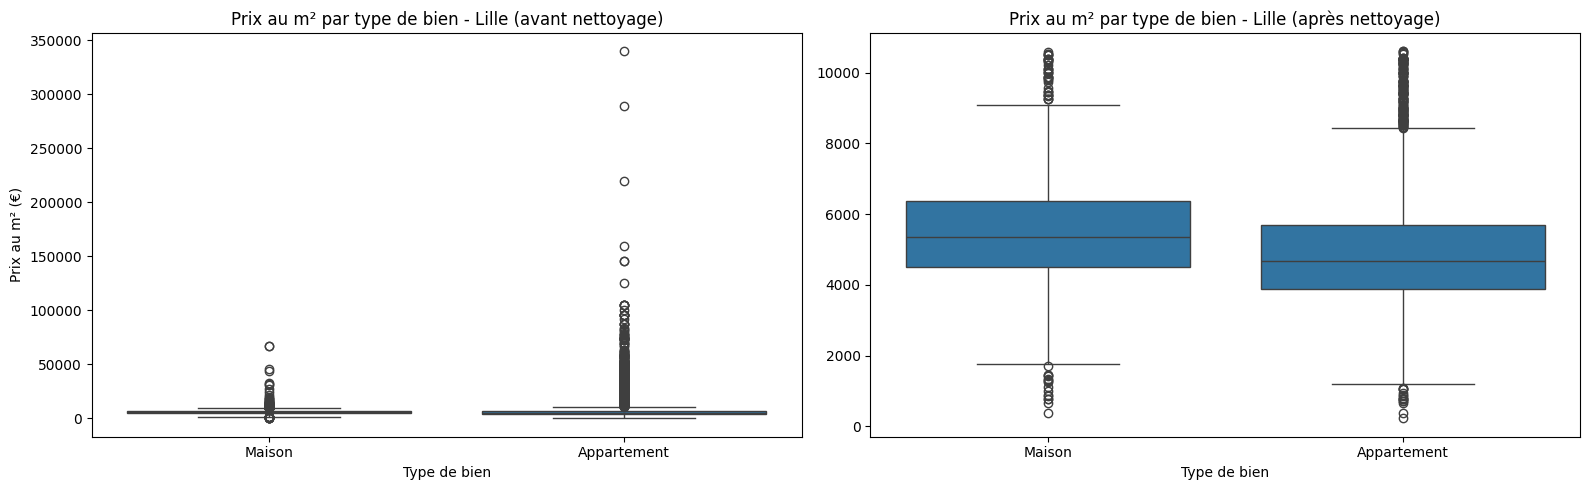

In [6]:

# Création des sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique avant nettoyage
sns.boxplot(x=df_bordeaux_row['Type local'], y=df_bordeaux_row['prix_m2'], ax=axes[0], showfliers=True)
axes[0].set_title("Prix au m² par type de bien - Lille (avant nettoyage)")
axes[0].set_xlabel("Type de bien")
axes[0].set_ylabel("Prix au m² (€)")

# Graphique après nettoyage
sns.boxplot(x= df_bordeaux_cleaned['Type local'], y=df_bordeaux_cleaned['prix_m2'], ax=axes[1], showfliers=True)
axes[1].set_title("Prix au m² par type de bien - Lille (après nettoyage)")
axes[1].set_xlabel("Type de bien")
axes[1].set_ylabel("")

# Affichage
plt.tight_layout()
plt.show()


## Sauvgarde du dataframe de Bordeaux après nettoyage

In [7]:
# Encodage du 'Type local' (catégorielle)
df_bordeaux = pd.get_dummies(df_bordeaux_cleaned, drop_first=True, dtype=int)
df_bordeaux.to_csv("../data/df_bordeaux.csv", index=False)
df_bordeaux

,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2,Type local_Maison
0,71.0,4.0,70.0,0,396000.0,5577.464789,1
1,40.0,1.0,0.0,1,158500.0,3962.500000,0
3,35.0,1.0,0.0,1,187000.0,5342.857143,0
5,65.0,3.0,45.0,0,312500.0,4807.692308,1
7,20.0,1.0,0.0,1,116000.0,5800.000000,0
...,...,...,...,...,...,...,...
13169,35.0,1.0,367.0,0,275000.0,7857.142857,1
13173,58.0,2.0,0.0,1,231000.0,3982.758621,0
13194,85.0,5.0,230.0,0,742000.0,8729.411765,1
13195,65.0,3.0,0.0,1,285000.0,4384.615385,0


## Matrice de corrélation

In [8]:
# Afficher la corrélation entre les variables numériques et la cible 'prix_m2'
df_bordeaux[['Surface reelle bati','Nombre pieces principales', 'Type local_Maison','Surface terrain', 'Nombre de lots', 'prix_m2']].corr()


,Surface reelle bati,Nombre pieces principales,Type local_Maison,Surface terrain,Nombre de lots,prix_m2
Surface reelle bati,1.000000,0.856313,0.501922,0.518577,-0.264198,-0.042437
Nombre pieces principales,0.856313,1.000000,0.509987,0.475146,-0.267196,-0.068825
Type local_Maison,0.501922,0.509987,1.000000,0.692494,-0.666154,0.162512
Surface terrain,0.518577,0.475146,0.692494,1.000000,-0.558012,0.192315
Nombre de lots,-0.264198,-0.267196,-0.666154,-0.558012,1.000000,-0.240724
prix_m2,-0.042437,-0.068825,0.162512,0.192315,-0.240724,1.000000


# 3. Test de généralisation du modèle sur bordeaux

In [9]:
# Données de test pour Bordeaux (prétraitées et nettoyées comme pour Lille)
# Variables explicatives et cible
features = ['Surface reelle bati','Nombre pieces principales', 'Type local_Maison', 'Surface terrain', 'Nombre de lots']
target = 'prix_m2'

X_test_bx = df_bordeaux[features]
y_test_bx = df_bordeaux[target]


### Standardisation

In [10]:
# Charger le scaler utilisé sur Lille
scaler_lille = joblib.load("../models/scaler_lille.pkl")

# Colonnes numériques à standardiser
num_features = ['Surface reelle bati', 'Nombre pieces principales', 'Surface terrain', 'Nombre de lots']

# Appliquer la transformation sur Bordeaux
X_test_bx[num_features] = scaler_lille.transform(X_test_bx[num_features])


C:\Users\adjah\AppData\Local\Temp\ipykernel_24280\1128195021.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_bx[num_features] = scaler_lille.transform(X_test_bx[num_features])


In [11]:


# Recharger les modèles et chemins
loaded_data = joblib.load("../models/model_lille.pkl")
models = loaded_data["models"]  # modèles rechargés


c:\Users\adjah\Desktop\Simplon\projets simplon\IA-Immobilier\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


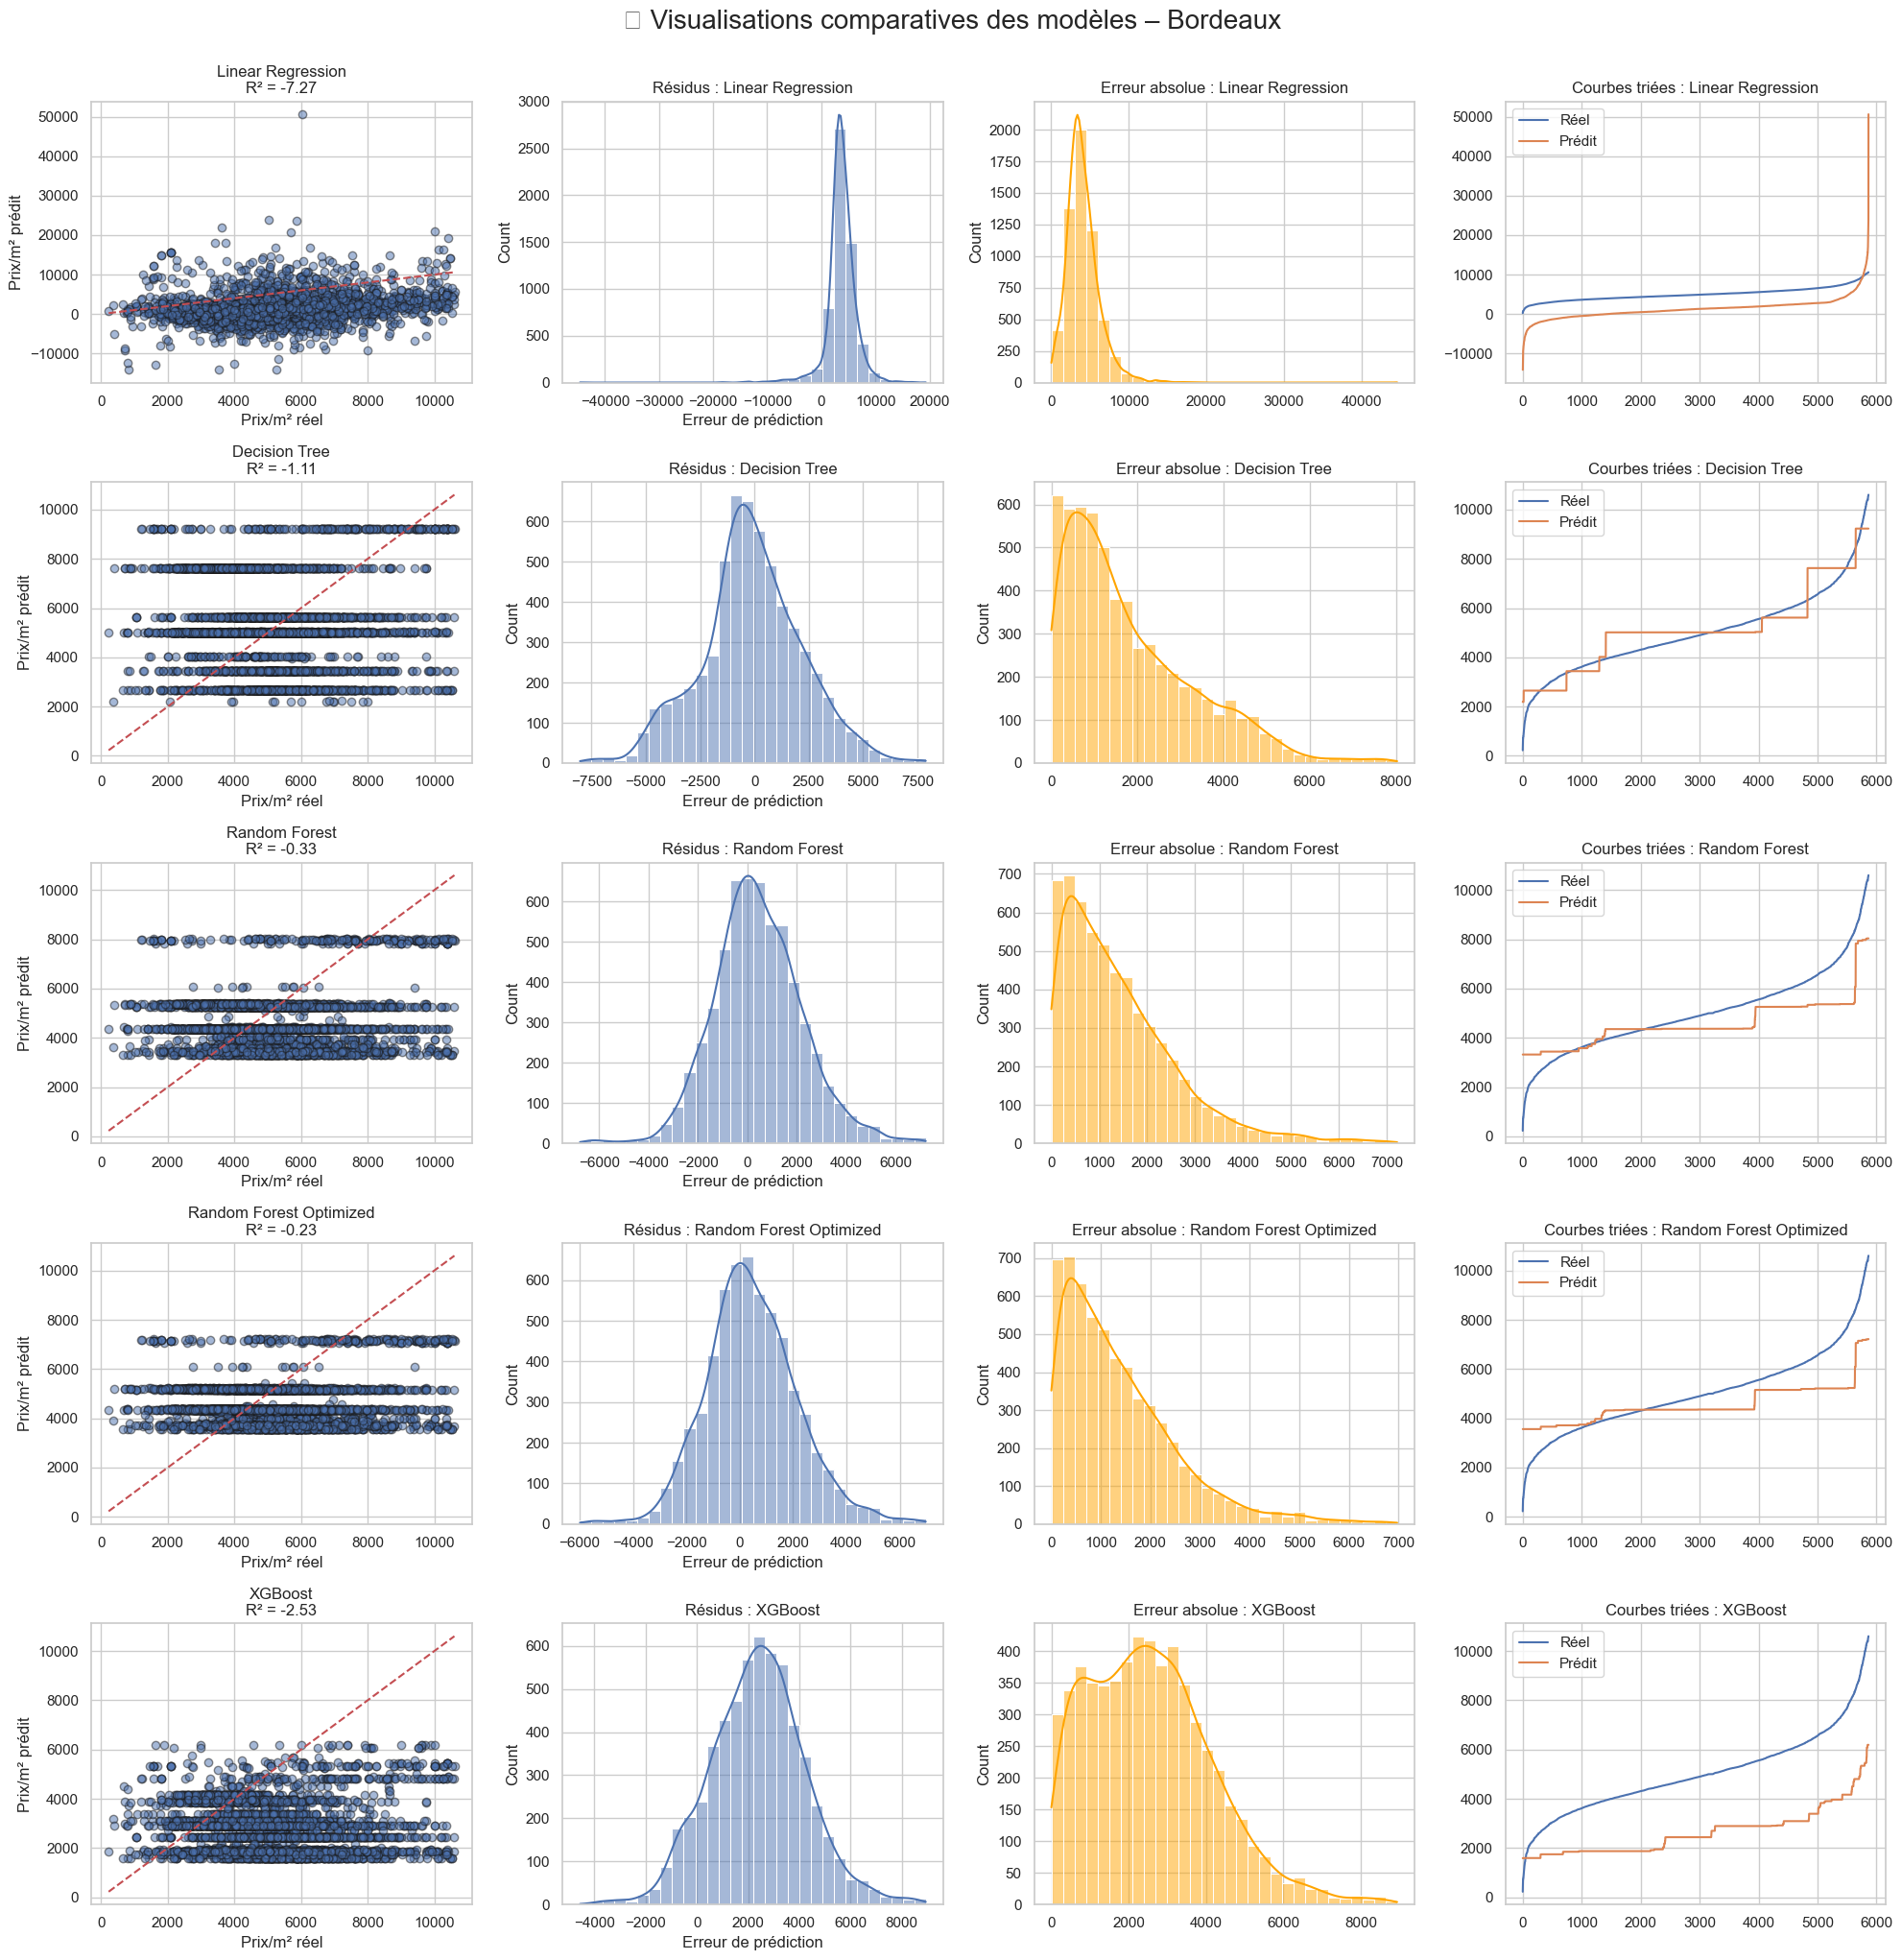

In [12]:
# Utiliser set_theme à la place de set (déprécié)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 20))
plot_idx = 1

# Utiliser 'models' à la place de 'models_bx'
for name, model in models.items():
    y_pred = model.predict(X_test_bx)
    # S'assurer que les shapes sont compatibles
    y_true = y_test_bx.values.ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    abs_errors = np.abs(residuals)

    # 1. Réel vs Prédit
    plt.subplot(len(models), 4, plot_idx)
    plt.scatter(y_true, y_pred, alpha=0.5, edgecolor='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Prix/m² réel")
    plt.ylabel("Prix/m² prédit")
    plt.title(f"{name}\nR² = {r2_score(y_true, y_pred):.2f}")
    plot_idx += 1

    # 2. Résidus
    plt.subplot(len(models), 4, plot_idx)
    sns.histplot(residuals, bins=30, kde=True)
    plt.title(f"Résidus : {name}")
    plt.xlabel("Erreur de prédiction")
    plot_idx += 1

    # 3. Erreurs absolues
    plt.subplot(len(models), 4, plot_idx)
    sns.histplot(abs_errors, bins=30, kde=True, color="orange")
    plt.title(f"Erreur absolue : {name}")
    plot_idx += 1

    # 4. Courbes des valeurs triées
    plt.subplot(len(models), 4, plot_idx)
    plt.plot(np.sort(y_true), label="Réel")
    plt.plot(np.sort(y_pred), label="Prédit")
    plt.title(f"Courbes triées : {name}")
    plt.legend()
    plot_idx += 1

plt.tight_layout()
plt.suptitle("📊 Visualisations comparatives des modèles – Bordeaux", fontsize=20, y=1.02)
plt.show()



# 4. Évaluation des performances



In [13]:
results = {
    "Modèle": [],
    "MSE": [],
    "RMSE": [],
    "R²": []
}

for name, model in models.items():
    y_pred = model.predict(X_test_bx)
    mse = mean_squared_error(y_test_bx, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_bx, y_pred)

    results["Modèle"].append(name)
    results["MSE"].append(mse)
    results["RMSE"].append(rmse)
    results["R²"].append(r2)

df_results_bx = pd.DataFrame(results).sort_values(by="MSE")
df_results_bx


,Modèle,MSE,RMSE,R²
3,Random Forest Optimized,3.203249e+06,1789.762338,-0.234065
2,Random Forest,3.451898e+06,1857.928473,-0.329858
1,Decision Tree,5.489183e+06,2342.900500,-1.114731
4,XGBoost,9.151248e+06,3025.103041,-2.525557
0,Linear Regression,2.146850e+07,4633.411704,-7.270831


# 🎯 Résultats   

Les résultats obtenus sur les données de Bordeaux montrent une performance nettement inférieure à celle observée sur Lille. En effet, tous les modèles évalués présentent un coefficient de détermination (R²) négatif, indiquant qu'ils prédisent moins bien que la moyenne simple des prix au m². Cette situation suggère que les modèles, tels qu'entraînés, ne sont pas adaptés aux spécificités du marché immobilier bordelais.

Plusieurs explications peuvent justifier ces résultats :

Différences structurelles entre les données de Bordeaux et Lille : la distribution des variables explicatives et du prix au m² peut différer sensiblement d’une ville à l’autre, ce qui rend les modèles entraînés sur Lille inadaptés pour Bordeaux.


Entraînement spécifique nécessaire : pour obtenir de bonnes performances, il est recommandé d’entraîner les modèles directement sur les données de Bordeaux, ou d’utiliser des techniques d’adaptation ou de transfert si l’on souhaite exploiter un modèle pré-entraîné.

Ces résultats mettent en évidence l’importance de personnaliser la préparation des données et la modélisation en fonction du contexte local pour garantir la pertinence et la robustesse des prédictions immobilières.